In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")

#Add the path for the feature-engineered data
DATA_PROCESSED_PATH = os.getenv("DATA_PROCESSED_PATH", "../data/processed/")    
FEATURE_ENGINEERED_DATA_FILENAME = os.getenv("FEATURE_ENGINEERED_DATA_FILENAME", "feature_engineered_house_data.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")

✅ Environment setup complete!


In [36]:
# Load your feature-engineered dataset
data_path = Path(DATA_PROCESSED_PATH)
df_fe = pd.read_csv(data_path / FEATURE_ENGINEERED_DATA_FILENAME)

print(f"Dataset shape: {df_fe.shape}")

#print columns of the dataset
print("\n--- Dataset Columns ---")
print(df_fe.columns)

Dataset shape: (4602, 29)

--- Dataset Columns ---
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'street', 'city', 'statezip',
       'house_age', 'renovated', 'renovation_age', 'log_price',
       'log_sqft_above', 'log_sqft_basement', 'log_sqft_lot',
       'sqft_per_bedroom', 'house_age_sq', 'basement_ratio',
       'bedrooms_per_sqft', 'bathrooms_per_sqft', 'bath_x_above',
       'waterfront_x_above', 'city_price_index', 'statezip_price_index',
       'knn_price'],
      dtype='object')


In [37]:
# VIF(Multicollinearity check): to verify that there is no multicollinearity among the features. 
# A VIF value above 5 or 10 indicates high multicollinearity, which can be problematic for linear models.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant   
# Prepare the data for VIF calculation
X = df_fe.drop(columns=['price', 'log_price', 'date', 'city', 'street', 'statezip'])  # Exclude target and non-numeric columns
X = add_constant(X)  # Add constant term for VIF calculation

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

#filter out the onstant and sort by VIF
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)  
print("\n--- VIF Scores ---")
print(vif_data) 


--- VIF Scores ---
                 Feature         VIF
2              bathrooms  933.012046
19          bath_x_above  848.770724
5             waterfront  225.041497
20    waterfront_x_above  224.964454
11        log_sqft_above   60.321519
16        basement_ratio   43.601278
8              house_age   29.299055
15          house_age_sq   23.613377
18    bathrooms_per_sqft   20.024541
1               bedrooms   15.994302
17     bedrooms_per_sqft   13.694815
12     log_sqft_basement   10.709235
14      sqft_per_bedroom    8.390632
23             knn_price    7.055754
13          log_sqft_lot    3.685671
22  statezip_price_index    2.996645
4                 floors    2.834508
21      city_price_index    2.788778
9              renovated    2.275787
3               sqft_lot    2.163207
10        renovation_age    1.766496
7              condition    1.622952
6                   view    1.334744


In [38]:
# remove reduntant features with high VIF and city, statezip and street as they are categorical and not directly used in modeling from the dataset.
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()  # Adjust threshold as needed
#categorical_features = ['city', 'statezip', 'street']
features_to_drop = high_vif_features # + categorical_features
print("\n--- Features to Drop ---")
print(features_to_drop)

#remove features to drop from the dataset
df_fe = df_fe.drop(columns=features_to_drop)
print(f"\nDataset shape after dropping features: {df_fe.shape}")

#print columns of the dataset after dropping features
print("\n--- Dataset Columns after dropping features ---")  
print(df_fe.columns)




--- Features to Drop ---
['bathrooms', 'bath_x_above', 'waterfront', 'waterfront_x_above', 'log_sqft_above', 'basement_ratio', 'house_age', 'house_age_sq', 'bathrooms_per_sqft', 'bedrooms', 'bedrooms_per_sqft', 'log_sqft_basement']

Dataset shape after dropping features: (4602, 17)

--- Dataset Columns after dropping features ---
Index(['date', 'price', 'sqft_lot', 'floors', 'view', 'condition', 'street',
       'city', 'statezip', 'renovated', 'renovation_age', 'log_price',
       'log_sqft_lot', 'sqft_per_bedroom', 'city_price_index',
       'statezip_price_index', 'knn_price'],
      dtype='object')


In [39]:
# Train-test split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_fe, test_size=0.2, random_state=42)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)


Train shape: (3681, 17)
Test shape: (921, 17)


In [47]:
# Build modeling matrices

# Columns to exclude from direct modeling
exclude_cols = ['price', 'log_price', 'date', 'city', 'street', 'statezip']

X_train = train_df.drop(columns=exclude_cols)
X_test = test_df.drop(columns=exclude_cols)

# Add city one-hot columns
#X_train = pd.concat([X_train_num.reset_index(drop=True), train_city.reset_index(drop=True)], axis=1)
#X_test = pd.concat([X_test_num.reset_index(drop=True), test_city.reset_index(drop=True)], axis=1)

# Align columns just in case
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_train = train_df['log_price']
y_test = test_df['log_price']
train_price = train_df['price']
test_price = test_df['price']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Number of features:', X_train.shape[1])

X_train shape: (3681, 11)
X_test shape: (921, 11)
Number of features: 11


In [48]:
# Baseline and regularized linear models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error


def evaluate_log_model(model, X_train, y_train, X_test, y_test, train_price, test_price):
    model.fit(X_train, y_train)

    pred_log_train = model.predict(X_train)
    pred_log_test = model.predict(X_test)

    pred_price_train = np.exp(pred_log_train)
    pred_price_test = np.exp(pred_log_test)

    train_mape = mean_absolute_percentage_error(train_price, pred_price_train)
    test_mape = mean_absolute_percentage_error(test_price, pred_price_test)
    return train_mape, test_mape

ols_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 20)))
])

lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(alphas=np.logspace(-4, 1, 30), cv=5, max_iter=20000, random_state=42))
])

elastic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-4, 1, 20),
        cv=5,
        max_iter=20000,
        random_state=42
    ))
])

results = []
for name, model in [
    ('OLS', ols_model),
    ('Ridge', ridge_model),
    ('Lasso', lasso_model),
    ('Elastic Net', elastic_model),
]:
    train_mape, test_mape = evaluate_log_model(model, X_train, y_train, X_test, y_test, train_price, test_price)
    results.append({'Model': name, 'Train_MAPE': train_mape, 'Test_MAPE': test_mape, 'Test_MAPE_pct': test_mape * 100})

linear_results = pd.DataFrame(results).sort_values('Test_MAPE')
print(linear_results)


         Model  Train_MAPE  Test_MAPE  Test_MAPE_pct
3  Elastic Net    0.236967   0.315746      31.574642
2        Lasso    0.236984   0.316483      31.648333
1        Ridge    0.236913   0.317199      31.719881
0          OLS    0.236964   0.317790      31.778998


In [49]:
# XGBoost benchmark
try:
    from xgboost import XGBRegressor
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost -q
    from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_train_mape, xgb_test_mape = evaluate_log_model(
    xgb_model, X_train, y_train, X_test, y_test, train_price, test_price
)

print(f'XGBoost Train MAPE: {xgb_train_mape:.4f} ({xgb_train_mape*100:.2f}%)')
print(f'XGBoost Test MAPE: {xgb_test_mape:.4f} ({xgb_test_mape*100:.2f}%)')

XGBoost Train MAPE: 0.1362 (13.62%)
XGBoost Test MAPE: 0.2780 (27.80%)


In [50]:
# Final model comparison
final_results = linear_results[['Model', 'Test_MAPE', 'Test_MAPE_pct']].copy()
final_results = pd.concat([    final_results,
    pd.DataFrame([{
        'Model': 'XGBoost',
        'Test_MAPE': xgb_test_mape,
        'Test_MAPE_pct': xgb_test_mape * 100
    }])
], ignore_index=True)

final_results = final_results.sort_values('Test_MAPE').reset_index(drop=True)
print(final_results)


         Model  Test_MAPE  Test_MAPE_pct
0      XGBoost   0.277956      27.795562
1  Elastic Net   0.315746      31.574642
2        Lasso   0.316483      31.648333
3        Ridge   0.317199      31.719881
4          OLS   0.317790      31.778998


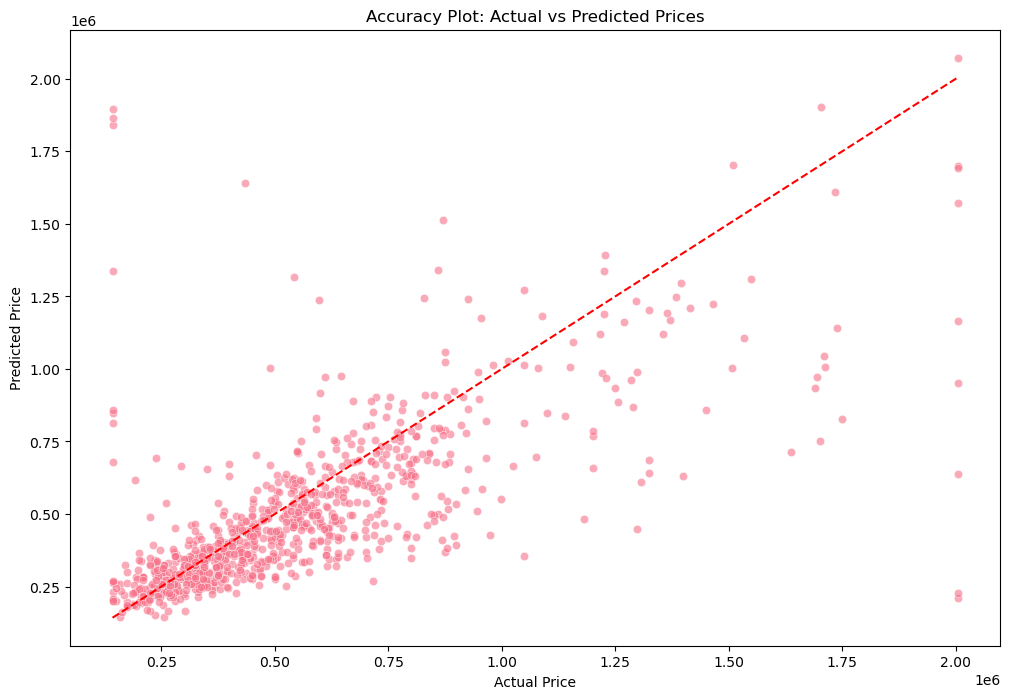

In [51]:
# Accuracy plot (Actual vs Predicted) for the best model (XGboost)
best_model = xgb_model     
plt.figure(figsize=(12, 8)) 
sns.scatterplot(x=np.exp(y_test), y=np.exp(best_model.predict(X_test)), alpha=0.6)
plt.plot([test_price.min(), test_price.max()], [test_price.min(), test_price.max()], 'r--')  # Diagonal line for reference
plt.xlabel('Actual Price')      
plt.ylabel('Predicted Price')
plt.title('Accuracy Plot: Actual vs Predicted Prices')
plt.show()


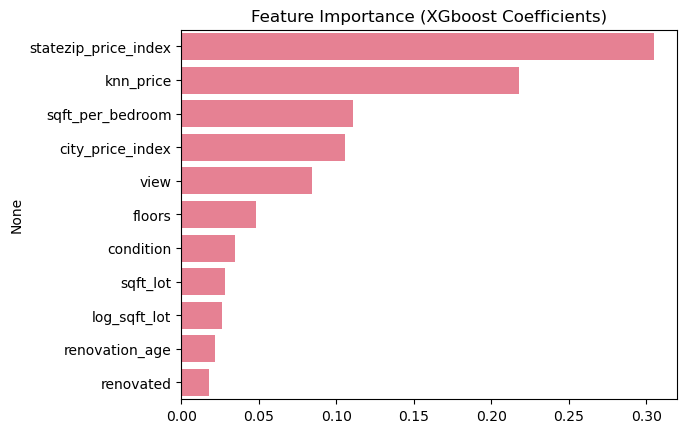

In [54]:
# Feature importance plot for the best linear model (XGboost)
feature_names = X_train.columns
feature_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)    
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Feature Importance (XGboost Coefficients)')
plt.show()



In [55]:
# feature importance in table form in ascednding order of importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_importance.index,
    'Importance': feature_importance.values
}).sort_values('Importance', ascending=False)
print(feature_importance_df)



                 Feature  Importance
0   statezip_price_index    0.304692
1              knn_price    0.217605
2       sqft_per_bedroom    0.110820
3       city_price_index    0.105825
4                   view    0.084187
5                 floors    0.048165
6              condition    0.034347
7               sqft_lot    0.028340
8           log_sqft_lot    0.026089
9         renovation_age    0.021978
10             renovated    0.017951
